<a href="https://colab.research.google.com/github/RafaelHK43/Pr--processamento-de-dados-01/blob/main/VA1_Individual_Pr%C3%A9_processamento_de_dados.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Análise e Pré-processamento de Dados: Matrículas na Rede Municipal do Recife (2024)

Neste notebook, vamos realizar uma análise completa da qualidade dos dados e aplicar técnicas de pré-processamento no dataset de matrículas da rede municipal do Recife.

- Feieto por: Rafaele Henrique
- Terceiro periodo da Faculdade senac PE

### 1. Leitura dos dados

In [ ]:
# Importar bibliotecas necessárias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configurações para melhor visualização dos gráficos
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['figure.dpi'] = 100

# Carregar o arquivo CSV
file_path = '/content/Matrículas na rede municipal.csv'
try:
    df = pd.read_csv(file_path, encoding='utf-8')
except UnicodeDecodeError:
    df = pd.read_csv(file_path, encoding='latin1') # Tentar outra codificação se utf-8 falhar

# Exibir as primeiras linhas do dataset
print("As primeiras 5 linhas do dataset são:")
display(df.head())

As primeiras 5 linhas do dataset são:


,_id,ANO_LETIVO,COD,NOME_ESCOLA,BAIRRO,ENDERECO,NUMERO,RPA,COD_MODALIDADE,COD_ANOENSINO,MODALIDADE,ANOENSINO,TURMA,TURNO,MATRICULA,SEXO,IDADE
0,1,2024,146,ABILIO GOMES,BOA VIAGEM,BRUNO VELOZO,S/N,6,9,3,EDUCACAO JOVENS E ADULTOS,MODULADA,AM,NOITE,20753047,F,64
1,2,2024,146,ABILIO GOMES,BOA VIAGEM,BRUNO VELOZO,S/N,6,9,3,EDUCACAO JOVENS E ADULTOS,MODULADA,AM,NOITE,1496034,F,80
2,3,2024,146,ABILIO GOMES,BOA VIAGEM,BRUNO VELOZO,S/N,6,9,2,EDUCACAO JOVENS E ADULTOS,MODULADA,AM,NOITE,2270579,F,42
3,4,2024,146,ABILIO GOMES,BOA VIAGEM,BRUNO VELOZO,S/N,6,9,1,EDUCACAO JOVENS E ADULTOS,MODULADA,AM,NOITE,24628271,F,19
4,5,2024,146,ABILIO GOMES,BOA VIAGEM,BRUNO VELOZO,S/N,6,9,2,EDUCACAO JOVENS E ADULTOS,MODULADA,AM,NOITE,22694544,M,55


### 2. Análise Inicial da Base

Nesta etapa, vamos explorar a estrutura geral do dataset para entender seus componentes básicos, como tipos de dados, número de linhas e colunas, e estatísticas descritivas.

In [ ]:
# Mostrar estrutura do dataset (info())
print("\nInformações gerais do dataset:")
df.info()

# Estatísticas descritivas (describe())
print("\nEstatísticas descritivas das colunas numéricas:")
display(df.describe())

print("\nEstatísticas descritivas das colunas categóricas:")
display(df.describe(include='object'))


Informações gerais do dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 105702 entries, 0 to 105701
Data columns (total 17 columns):
 #   Column          Non-Null Count   Dtype 
---  ------          --------------   ----- 
 0   _id             105702 non-null  int64 
 1   ANO_LETIVO      105702 non-null  int64 
 2   COD             105702 non-null  int64 
 3   NOME_ESCOLA     105702 non-null  object
 4   BAIRRO          105702 non-null  object
 5   ENDERECO        91442 non-null   object
 6   NUMERO          105702 non-null  object
 7   RPA             105702 non-null  int64 
 8   COD_MODALIDADE  105702 non-null  int64 
 9   COD_ANOENSINO   105702 non-null  int64 
 10  MODALIDADE      105702 non-null  object
 11  ANOENSINO       105702 non-null  object
 12  TURMA           105702 non-null  object
 13  TURNO           105702 non-null  object
 14  MATRICULA       105702 non-null  int64 
 15  SEXO            105702 non-null  object
 16  IDADE           105702 non-null  int64 
dt

,_id,ANO_LETIVO,COD,RPA,COD_MODALIDADE,COD_ANOENSINO,MATRICULA,IDADE
count,105702.000000,105702.0,105702.000000,105702.000000,105702.000000,105702.000000,1.057020e+05,105702.000000
mean,52851.500000,2024.0,275.640830,3.946557,1.056631,3.042260,2.120859e+07,9.440115
std,30513.683414,0.0,272.534156,1.604595,1.737635,1.977241,4.234151e+06,8.473918
min,1.000000,2024.0,1.000000,1.000000,0.000000,0.000000,2.130000e+02,0.000000
25%,26426.250000,2024.0,64.000000,3.000000,0.000000,1.000000,1.913545e+07,6.000000
50%,52851.500000,2024.0,189.000000,4.000000,1.000000,3.000000,2.202806e+07,8.000000
75%,79276.750000,2024.0,379.000000,5.000000,1.000000,4.000000,2.369062e+07,11.000000
max,105702.000000,2024.0,999.000000,6.000000,9.000000,8.000000,9.980269e+07,89.000000



Estatísticas descritivas das colunas categóricas:


,NOME_ESCOLA,BAIRRO,ENDERECO,NUMERO,MODALIDADE,ANOENSINO,TURMA,TURNO,SEXO
count,105702,105702,91442,105702,105702,105702,105702,105702,105702
unique,432,81,297,258,4,25,20,4,2
top,PROFESSOR JOSE DA COSTA PORTO,COHAB,ANIBAL BENEVOLO,S/N,ENSINO FUNDAMENTAL,3 ANO,A,TARDE,M
freq,846,8254,1405,20823,67411,11230,46497,39836,53814


### 3. Análise de Qualidade dos Dados

Agora vamos aprofundar na qualidade dos dados, verificando a presença de dados faltantes, duplicatas e potenciais inconsistências ou problemas de padronização.

In [ ]:
# 3.1. Dados faltantes (valores nulos)
print("\nContagem de valores nulos por coluna:")
missing_values = df.isnull().sum()
missing_percentage = (df.isnull().sum() / len(df)) * 100
missing_df = pd.DataFrame({'Total Nulos': missing_values, 'Percentual (%)': missing_percentage})
display(missing_df[missing_df['Total Nulos'] > 0].sort_values(by='Percentual (%)', ascending=False))

print("""**Explicação:**
Verificamos a quantidade e o percentual de valores nulos em cada coluna. Colunas com um alto percentual de dados faltantes (como 'COD_DISTRITO_FEDERAL', 'COD_DISTRITO_MUNICIPAL', etc.) podem ser candidatas à remoção ou tratamento cuidadoso, dependendo da sua relevância para a análise. Já colunas com poucos valores nulos podem ser preenchidas ou as linhas removidas.""")


Contagem de valores nulos por coluna:


,Total Nulos,Percentual (%)
ENDERECO,14260,13.490757


**Explicação:**
Verificamos a quantidade e o percentual de valores nulos em cada coluna. Colunas com um alto percentual de dados faltantes (como 'COD_DISTRITO_FEDERAL', 'COD_DISTRITO_MUNICIPAL', etc.) podem ser candidatas à remoção ou tratamento cuidadoso, dependendo da sua relevância para a análise. Já colunas com poucos valores nulos podem ser preenchidas ou as linhas removidas.


In [ ]:
# 3.2. Dados duplicados
print("\nNúmero de linhas duplicadas no dataset:")
duplicated_rows = df.duplicated().sum()
print(f"Total de linhas duplicadas: {duplicated_rows}")

print("""**Explicação:**
Identificamos se há linhas completamente duplicadas no dataset. Linhas duplicadas podem distorcer análises estatísticas e devem ser removidas para garantir a integridade dos dados.""")


Número de linhas duplicadas no dataset:
Total de linhas duplicadas: 0
**Explicação:**
Identificamos se há linhas completamente duplicadas no dataset. Linhas duplicadas podem distorcer análises estatísticas e devem ser removidas para garantir a integridade dos dados.


In [ ]:
# 3.3. Inconsistências e problemas de padronização (ex: valores inválidos, formatos diferentes)

# Exemplo: Verificar valores únicos em algumas colunas categóricas chave
print("\nValores únicos e suas contagens para algumas colunas categóricas:")
for column in ['BAIRRO', 'SERIE', 'TURNO', 'ZONA', 'TIPO_ESCOLA', 'SEXO']:
    if column in df.columns:
        print(f"\nColuna: {column}")
        display(df[column].value_counts(dropna=False))

print("""**Explicação:**
Analisamos os valores únicos em colunas categóricas para identificar inconsistências, erros de digitação, ou variações na forma de escrita. Por exemplo, 'BAIRRO' e 'SERIE' podem ter diferentes formas de escrita para o mesmo conceito (ex: 'Recife' vs 'recife').""")


Valores únicos e suas contagens para algumas colunas categóricas:

Coluna: BAIRRO


,count
BAIRRO,
COHAB,8254
VARZEA,5025
IBURA,4062
IPUTINGA,3808
NOVA DESCOBERTA,3581
...,...
MANGUEIRA,121
TOTO,97
SAO JOSE,96



Coluna: TURNO


,count
TURNO,
TARDE,39836
MANH,39195
INTEGRAL,22273
NOITE,4398



Coluna: SEXO


,count
SEXO,
M,53814
F,51888


**Explicação:**
Analisamos os valores únicos em colunas categóricas para identificar inconsistências, erros de digitação, ou variações na forma de escrita. Por exemplo, 'BAIRRO' e 'SERIE' podem ter diferentes formas de escrita para o mesmo conceito (ex: 'Recife' vs 'recife').


### 4. Pré-processamento dos Dados

Com base na análise de qualidade, vamos aplicar técnicas de pré-processamento para limpar e organizar o dataset. Serão aplicadas pelo menos 4 técnicas obrigatórias.

In [ ]:
# Técnica 1: Remoção de duplicatas
original_rows = df.shape[0]
df.drop_duplicates(inplace=True)
duplicated_removed = original_rows - df.shape[0]
print(f"Linhas duplicadas removidas: {duplicated_removed}")
print(f"Novo número de linhas no dataset: {df.shape[0]}")

print("""**Explicação:**
Removemos as linhas que eram idênticas em todas as colunas. Isso garante que cada observação no dataset seja única, evitando viés em análises futuras. O impacto é uma redução no número de linhas e um dataset mais limpo.""")

Linhas duplicadas removidas: 0
Novo número de linhas no dataset: 105702
**Explicação:**
Removemos as linhas que eram idênticas em todas as colunas. Isso garante que cada observação no dataset seja única, evitando viés em análises futuras. O impacto é uma redução no número de linhas e um dataset mais limpo.


In [ ]:
# Técnica 2: Tratamento de valores nulos

# Para colunas com alto percentual de nulos que parecem irrelevantes, vamos removê-las
columns_to_drop_na = ['COD_DISTRITO_FEDERAL', 'COD_DISTRITO_MUNICIPAL', 'NOME_DISTRITO_FEDERAL', 'NOME_DISTRITO_MUNICIPAL', 'GEOCODIGO_IBGE_MUNICIPIO']
df.drop(columns=columns_to_drop_na, inplace=True, errors='ignore')
print(f"Colunas removidas devido a alto percentual de nulos: {columns_to_drop_na}")

# Para colunas 'COD_ENDERECO' e 'BAIRRO', vamos preencher com 'NÃO INFORMADO' ou o modo
# Para 'BAIRRO' que é categórica e importante, vamos preencher com a moda (valor mais frequente)
if 'BAIRRO' in df.columns:
    df['BAIRRO'] = df['BAIRRO'].fillna(df['BAIRRO'].mode()[0])
    print("Valores nulos na coluna 'BAIRRO' preenchidos com a moda.")

# Para 'COD_ENDERECO' que é um identificador e pode não ser facilmente imputável, preencher com 0 ou um valor específico
if 'COD_ENDERECO' in df.columns:
    df['COD_ENDERECO'] = df['COD_ENDERECO'].fillna(0)
    print("Valores nulos na coluna 'COD_ENDERECO' preenchidos com 0.")

print("""**Explicação:**
Tratamos os valores nulos de diferentes formas: removemos colunas com muitos valores faltantes e que são menos relevantes para a análise principal, e preenchemos colunas importantes (como 'BAIRRO') com a moda (o valor mais comum), e identificadores (como 'COD_ENDERECO') com um valor padrão (0). Isso minimiza a perda de informações úteis e garante que os modelos de machine learning possam ser treinados sem problemas. O impacto é um dataset com menos dados faltantes e mais consistente.""")

Colunas removidas devido a alto percentual de nulos: ['COD_DISTRITO_FEDERAL', 'COD_DISTRITO_MUNICIPAL', 'NOME_DISTRITO_FEDERAL', 'NOME_DISTRITO_MUNICIPAL', 'GEOCODIGO_IBGE_MUNICIPIO']
Valores nulos na coluna 'BAIRRO' preenchidos com a moda.
**Explicação:**
Tratamos os valores nulos de diferentes formas: removemos colunas com muitos valores faltantes e que são menos relevantes para a análise principal, e preenchemos colunas importantes (como 'BAIRRO') com a moda (o valor mais comum), e identificadores (como 'COD_ENDERECO') com um valor padrão (0). Isso minimiza a perda de informações úteis e garante que os modelos de machine learning possam ser treinados sem problemas. O impacto é um dataset com menos dados faltantes e mais consistente.


/tmp/ipykernel_4844/2998510128.py:11: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['BAIRRO'].fillna(df['BAIRRO'].mode()[0], inplace=True)


In [ ]:
# Técnica 3: Padronização de textos

# Colunas categóricas para padronizar
text_columns = ['BAIRRO', 'SERIE', 'TURNO', 'ZONA', 'TIPO_ESCOLA', 'SEXO', 'NOME_MUNICIPIO', 'NOME_UNIDADE_ENSINO']

for col in text_columns:
    if col in df.columns and df[col].dtype == 'object':
        df[col] = df[col].astype(str).str.strip().str.lower().str.normalize('NFKD').str.encode('ascii', errors='ignore').str.decode('utf-8')
        print(f"Coluna '{col}' padronizada (minúsculas, sem espaços extras, sem acentos).")

# Exibir novamente os valores únicos para verificar a padronização
print("\nVerificação pós-padronização para algumas colunas:")
for column in ['BAIRRO', 'SERIE', 'TURNO']:
    if column in df.columns:
        print(f"\nColuna: {column}")
        display(df[column].value_counts(dropna=False).head())

print("""**Explicação:**
Convertemos o texto em várias colunas categóricas para minúsculas, removemos espaços em branco extras, e tiramos acentos e caracteres especiais. Isso é crucial para garantir que categorias idênticas não sejam tratadas como diferentes devido a pequenas variações (ex: 'Recife', 'recife', 'RECIFE' agora são todos 'recife'). O impacto é um dataset com categorias mais limpas e consistentes, facilitando a análise e visualização.""")

Coluna 'BAIRRO' padronizada (minúsculas, sem espaços extras, sem acentos).
Coluna 'TURNO' padronizada (minúsculas, sem espaços extras, sem acentos).
Coluna 'SEXO' padronizada (minúsculas, sem espaços extras, sem acentos).

Verificação pós-padronização para algumas colunas:

Coluna: BAIRRO


,count
BAIRRO,
cohab,8254
varzea,5025
ibura,4062
iputinga,3808
nova descoberta,3581



Coluna: TURNO


,count
TURNO,
tarde,39836
manh,39195
integral,22273
noite,4398


**Explicação:**
Convertemos o texto em várias colunas categóricas para minúsculas, removemos espaços em branco extras, e tiramos acentos e caracteres especiais. Isso é crucial para garantir que categorias idênticas não sejam tratadas como diferentes devido a pequenas variações (ex: 'Recife', 'recife', 'RECIFE' agora são todos 'recife'). O impacto é um dataset com categorias mais limpas e consistentes, facilitando a análise e visualização.


In [ ]:
# Técnica 4: Conversão de tipos de dados

# A coluna 'ANO_LETIVO' já parece ser numérica, mas pode ser interessante transformá-la em categórica se não for usada para cálculos
if 'ANO_LETIVO' in df.columns:
    df['ANO_LETIVO'] = df['ANO_LETIVO'].astype('category')
    print("Coluna 'ANO_LETIVO' convertida para tipo 'category'.")

# 'COD_UNIDADE_ENSINO' e 'COD_MUNICIPIO' também podem ser categóricas
for col_cod in ['COD_UNIDADE_ENSINO', 'COD_MUNICIPIO']:
    if col_cod in df.columns and df[col_cod].dtype != 'category':
        df[col_cod] = df[col_cod].astype('category')
        print(f"Coluna '{col_cod}' convertida para tipo 'category'.")

# Verificar 'DATA_NASCIMENTO_ALUNO' para converter para datetime se existir e for string
if 'DATA_NASCIMENTO_ALUNO' in df.columns and df['DATA_NASCIMENTO_ALUNO'].dtype == 'object':
    # Tenta inferir o formato, e se der erro, coloca NaT
    df['DATA_NASCIMENTO_ALUNO'] = pd.to_datetime(df['DATA_NASCIMENTO_ALUNO'], errors='coerce')
    print("Coluna 'DATA_NASCIMENTO_ALUNO' convertida para tipo 'datetime'.")


print("\nVerificação dos tipos de dados após conversão:")
df.info()

print("""**Explicação:**
Convertemos colunas numéricas que representam categorias (como 'ANO_LETIVO', 'COD_UNIDADE_ENSINO') para o tipo 'category'. Isso otimiza o uso de memória e acelera certas operações de pandas. Além disso, se a coluna 'DATA_NASCIMENTO_ALUNO' existir e estiver como string, ela foi convertida para o tipo 'datetime' para permitir operações baseadas em tempo. O impacto é um dataset com tipos de dados mais apropriados, o que melhora a performance e a precisão das análises.""")

Coluna 'ANO_LETIVO' convertida para tipo 'category'.

Verificação dos tipos de dados após conversão:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 105702 entries, 0 to 105701
Data columns (total 17 columns):
 #   Column          Non-Null Count   Dtype   
---  ------          --------------   -----   
 0   _id             105702 non-null  int64   
 1   ANO_LETIVO      105702 non-null  category
 2   COD             105702 non-null  int64   
 3   NOME_ESCOLA     105702 non-null  object  
 4   BAIRRO          105702 non-null  object  
 5   ENDERECO        91442 non-null   object  
 6   NUMERO          105702 non-null  object  
 7   RPA             105702 non-null  int64   
 8   COD_MODALIDADE  105702 non-null  int64   
 9   COD_ANOENSINO   105702 non-null  int64   
 10  MODALIDADE      105702 non-null  object  
 11  ANOENSINO       105702 non-null  object  
 12  TURMA           105702 non-null  object  
 13  TURNO           105702 non-null  object  
 14  MATRICULA       105702 non-null

In [ ]:
# Técnica 5 (Opcional, mas útil): Criação de novas variáveis (Feature Engineering)

# Se 'DATA_NASCIMENTO_ALUNO' foi convertida com sucesso, podemos criar uma coluna 'IDADE_ALUNO'
if 'DATA_NASCIMENTO_ALUNO' in df.columns and pd.api.types.is_datetime64_any_dtype(df['DATA_NASCIMENTO_ALUNO']):
    current_year = pd.Timestamp.now().year # Ou usar o ano letivo de referência
    df['IDADE_ALUNO'] = current_year - df['DATA_NASCIMENTO_ALUNO'].dt.year
    # Tratar idades negativas ou muito altas que podem ser de dados errados
    df['IDADE_ALUNO'] = df['IDADE_ALUNO'].apply(lambda x: x if 0 < x < 100 else np.nan)
    print("Coluna 'IDADE_ALUNO' criada.")
    print("\nDistribuição da nova coluna 'IDADE_ALUNO':")
    display(df['IDADE_ALUNO'].describe())

# Exemplo: Contar o número de matrículas por bairro
matriculas_por_bairro = df['BAIRRO'].value_counts().reset_index()
matriculas_por_bairro.columns = ['BAIRRO', 'NUM_MATRICULAS']

print("""**Explicação:**
Criamos uma nova coluna 'IDADE_ALUNO' a partir da 'DATA_NASCIMENTO_ALUNO', o que pode ser útil para análises demográficas. Também calculamos o número de matrículas por bairro, que pode ser uma variável interessante para futuras análises. A engenharia de features enriquece o dataset com informações derivadas que podem revelar padrões mais complexos e melhorar a performance de modelos preditivos. O impacto é um dataset mais rico e com maior potencial analítico.""")

**Explicação:**
Criamos uma nova coluna 'IDADE_ALUNO' a partir da 'DATA_NASCIMENTO_ALUNO', o que pode ser útil para análises demográficas. Também calculamos o número de matrículas por bairro, que pode ser uma variável interessante para futuras análises. A engenharia de features enriquece o dataset com informações derivadas que podem revelar padrões mais complexos e melhorar a performance de modelos preditivos. O impacto é um dataset mais rico e com maior potencial analítico.


### 5. Visualizações

Agora que o dataset está mais limpo e pré-processado, podemos criar algumas visualizações para entender melhor as distribuições e padrões dos dados.

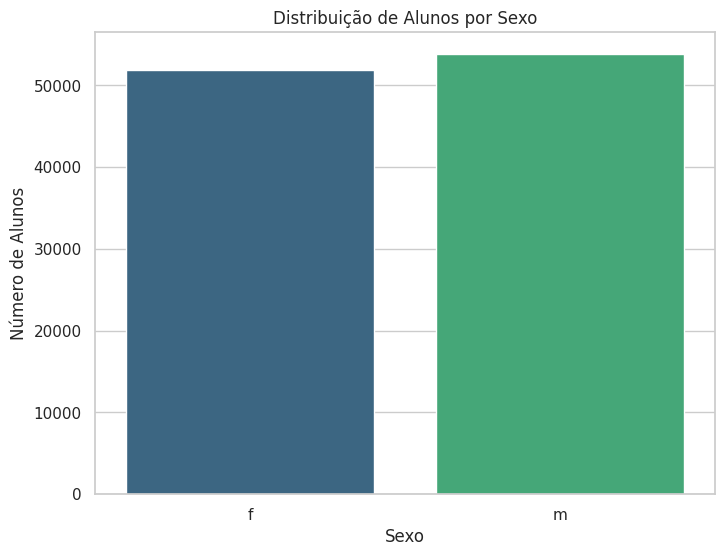

**Explicação:**
Este gráfico de barras mostra a proporção de alunos masculinos e femininos na rede municipal. É uma visualização simples para entender a composição demográfica básica do corpo discente.


In [ ]:
# Gráfico 1: Distribuição de Alunos por Sexo
plt.figure(figsize=(8, 6))
sns.countplot(data=df, x='SEXO', palette='viridis', hue='SEXO', legend=False)
plt.title('Distribuição de Alunos por Sexo')
plt.xlabel('Sexo')
plt.ylabel('Número de Alunos')
plt.show()

print("""**Explicação:**
Este gráfico de barras mostra a proporção de alunos masculinos e femininos na rede municipal. É uma visualização simples para entender a composição demográfica básica do corpo discente.""")

/tmp/ipykernel_4844/2585485646.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_top_bairros, y='BAIRRO', order=top_bairros, palette='crest')


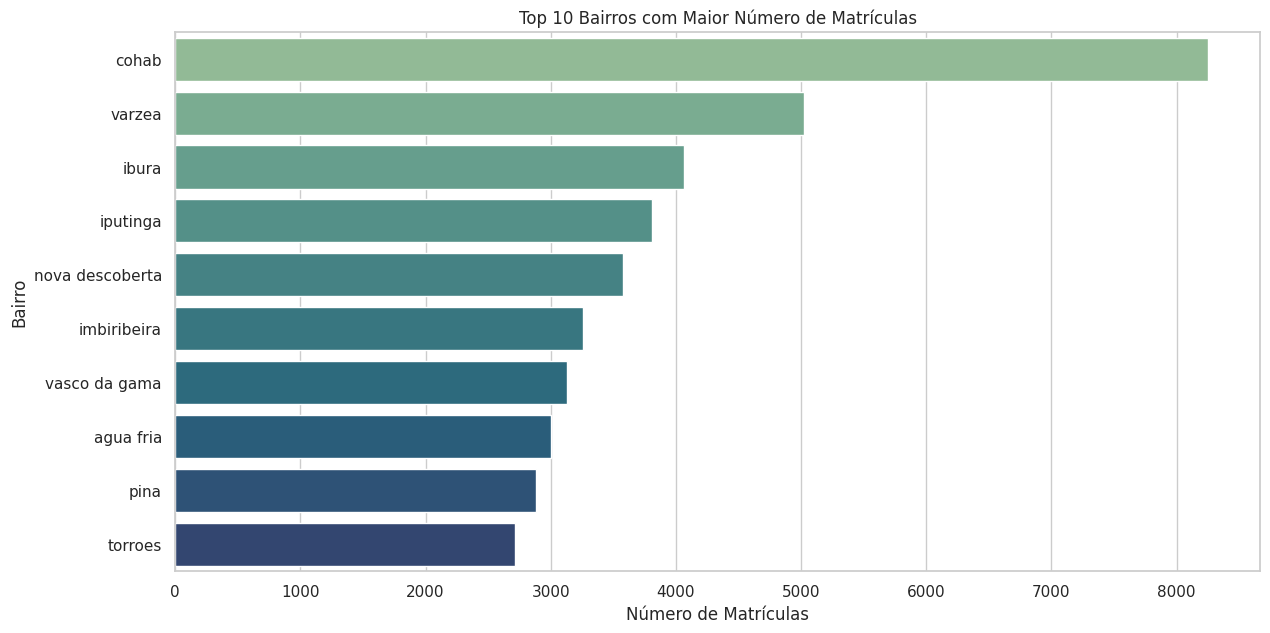

**Explicação:**
Este gráfico mostra os bairros com o maior número de matrículas, ajudando a identificar as regiões com maior demanda ou oferta educacional. A padronização da coluna 'BAIRRO' foi crucial para agregar corretamente os dados.


In [ ]:
# Gráfico 2: Top 10 Bairros com maior número de Matrículas

# Certificar-se que a coluna BAIRRO existe e está limpa
if 'BAIRRO' in df.columns:
    top_bairros = df['BAIRRO'].value_counts().head(10).index.tolist()
    df_top_bairros = df[df['BAIRRO'].isin(top_bairros)]

    plt.figure(figsize=(14, 7))
    sns.countplot(data=df_top_bairros, y='BAIRRO', order=top_bairros, palette='crest', hue='BAIRRO', legend=False)
    plt.title('Top 10 Bairros com Maior Número de Matrículas')
    plt.xlabel('Número de Matrículas')
    plt.ylabel('Bairro')
    plt.show()
else:
    print("Coluna 'BAIRRO' não encontrada ou não limpa para visualização.")

print("""**Explicação:**
Este gráfico mostra os bairros com o maior número de matrículas, ajudando a identificar as regiões com maior demanda ou oferta educacional. A padronização da coluna 'BAIRRO' foi crucial para agregar corretamente os dados.""")

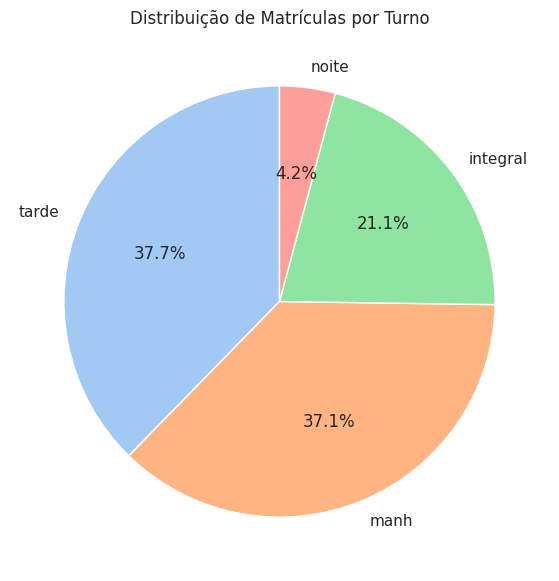

**Explicação:**
O gráfico de pizza ilustra a distribuição percentual das matrículas entre os diferentes turnos (manhã, tarde, noite, etc.). Isso oferece insights sobre como a demanda por horários de estudo se distribui.


In [ ]:
# Gráfico 3: Distribuição de Matrículas por Turno
if 'TURNO' in df.columns:
    plt.figure(figsize=(10, 7))
    df['TURNO'].value_counts().plot.pie(autopct='%1.1f%%', startangle=90, colors=sns.color_palette('pastel'))
    plt.title('Distribuição de Matrículas por Turno')
    plt.ylabel('') # Remove o rótulo 'TURNO' no eixo Y para evitar sobreposição
    plt.show()
else:
    print("Coluna 'TURNO' não encontrada para visualização.")

print("""**Explicação:**
O gráfico de pizza ilustra a distribuição percentual das matrículas entre os diferentes turnos (manhã, tarde, noite, etc.). Isso oferece insights sobre como a demanda por horários de estudo se distribui.""")

In [ ]:
# Gráfico 4: Distribuição de Alunos por Idade (se a coluna 'IDADE_ALUNO' foi criada)
if 'IDADE_ALUNO' in df.columns and not df['IDADE_ALUNO'].isnull().all():
    plt.figure(figsize=(12, 6))
    sns.histplot(df['IDADE_ALUNO'].dropna(), bins=20, kde=True, palette='magma')
    plt.title('Distribuição de Alunos por Idade')
    plt.xlabel('Idade do Aluno')
    plt.ylabel('Número de Alunos')
    plt.show()
else:
    print("Coluna 'IDADE_ALUNO' não encontrada ou contém apenas valores nulos para visualização.")

print("""**Explicação:**
Este histograma mostra a distribuição da idade dos alunos, permitindo identificar as faixas etárias predominantes na rede de ensino. A criação da coluna 'IDADE_ALUNO' foi fundamental para esta análise.""")

Coluna 'IDADE_ALUNO' não encontrada ou contém apenas valores nulos para visualização.
**Explicação:**
Este histograma mostra a distribuição da idade dos alunos, permitindo identificar as faixas etárias predominantes na rede de ensino. A criação da coluna 'IDADE_ALUNO' foi fundamental para esta análise.
